<a href="https://colab.research.google.com/github/LuisManuelCatzoliSoriano/Procesos-Estoc-sticos/blob/main/MMCvCM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Método de Monte Carlo vía Cadenas de Markov

Ejemplo: Obtener una muestra de

$$\pi(x)\approx e^{- \frac{x^2}{2}}(1+0.3sen(5x))$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random as r


In [2]:
def pi_x(x):
    return np.exp(- (x**2) / 2) * (1 + 0.3 * np.sin(5 * x))

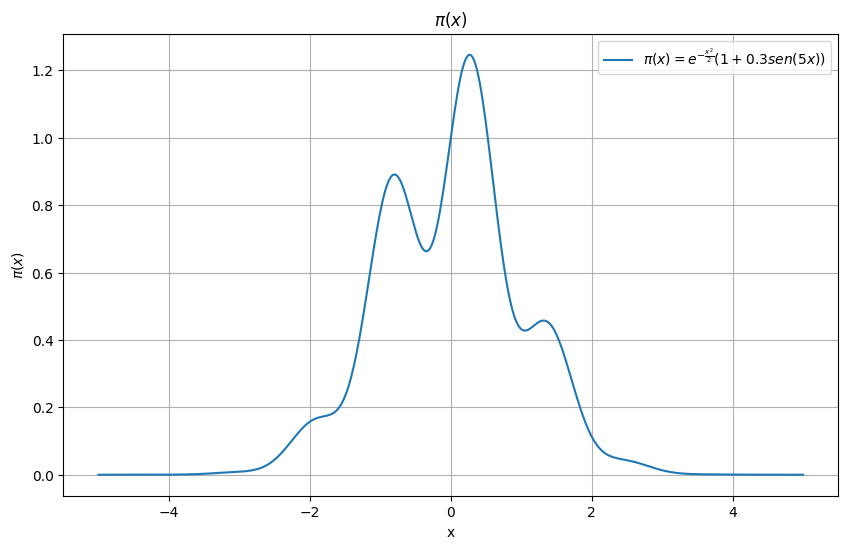

In [6]:
x_values = np.linspace(-5, 5, 500)

y_values = pi_x(x_values)

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label=r'$\pi(x)=e^{- \frac{x^2}{2}}(1+0.3sen(5x))$')
plt.title(r'$\pi(x)$')
plt.xlabel('x')
plt.ylabel(r'$\pi(x)$')
plt.grid(True)
plt.legend()
plt.show()

In [17]:
def metropolis(n, sigma=0.5, x0=1):

    muestras = []
    x_actual = x0

    for i in range(n):

        x_propuesta = np.random.normal(x_actual, sigma)

        if x_propuesta <= 0:
            muestras.append(x_actual)
            continue

        alpha = min(1, pi_x(x_propuesta) / pi_x(x_actual))

        u = np.random.rand()

        if u <= alpha:
            x_actual = x_propuesta

        muestras.append(x_actual)

    return np.array(muestras)


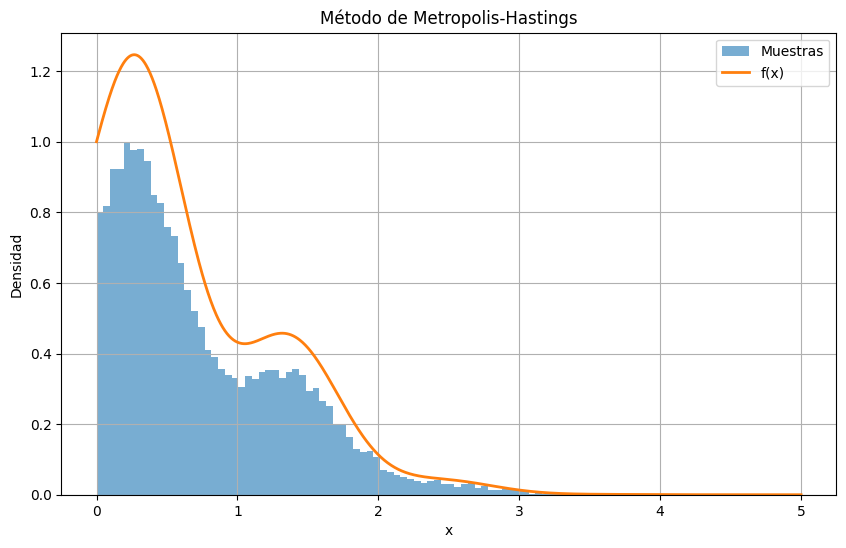

In [16]:
n = 50000
muestras = metropolis(n)


x = np.linspace(0, 5, 1000)

plt.figure(figsize=(10,6))

plt.hist(muestras,
         bins=80,
         density="True",
         alpha=0.6,
         label="Muestras")

plt.plot(x, pi_x(x),
         linewidth=2,
         label="f(x)")

plt.xlabel("x")
plt.ylabel("Densidad")
plt.title("Método de Metropolis-Hastings")
plt.legend()
plt.grid()
plt.show()